In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import SymLogNorm
from matplotlib.gridspec import GridSpec
from matplotlib.colors import Normalize
from magnonics import *

In [2]:
slab, _, _ = Initialize.from_csv('configs_slab/kagome_flat_flat.csv')

slab.HP_trafo(symbolic=True)

slab.parameterize_hamil(1e-8)

1e-08

In [3]:
slab.update_parameters({'Dz': 0.1}, chempot=1e-3)

Updated parameters and now using 0.001 as chemical potential.


In [4]:
dir = slab.lat.num_rcpr_vects[0]
ks = np.linspace(0, 1, 500)
energies = np.empty((len(ks), 2*slab.lat.n_sublats))
amps = np.empty((len(ks), slab.lat.n_sublats, slab.lat.n_sublats))
eigvects = np.empty((len(ks), 2*slab.lat.n_sublats, 2*slab.lat.n_sublats), dtype='complex')

for i, j in enumerate(ks):
    k = j*dir # cut dir vector into len(ks)-1 pieces
    E, EV = slab.Bogoliubov_trafo(k[0], k[1], k[2])
    amp = slab.sublat_localization(EV)
    energies[i] = E
    amps[i] = amp
    eigvects[i] = EV

energies = energies[:, :len(energies[1]) // 2]

In [5]:
loc = amps[:, :, -8:].sum(axis=-1) - amps[:, :, :8].sum(axis=-1)
# zigzag armchair [59 - i for i in range(12)], [i for i in range(12)]
# double zigzag [59 - i for i in range(13)], [i for i in range(12)] + [60]
# double armchair [61 - i for i in range(14)], [i for i in range(12)] + [12, 15]

tol = 1e-5
degen_mask = np.zeros_like(energies, dtype=bool)

nk, nbands = energies.shape

for i in range(nk):
    e_on_k = energies[i, :]

    for j in range(nbands):
        if j > 0 and np.abs(e_on_k[j] - e_on_k[j-1]) < tol:
            degen_mask[i, j] = True
        if j < (nbands-1) and np.abs(e_on_k[j] - e_on_k[j+1]) < tol:
            degen_mask[i, j] = True

loc[degen_mask] = 0

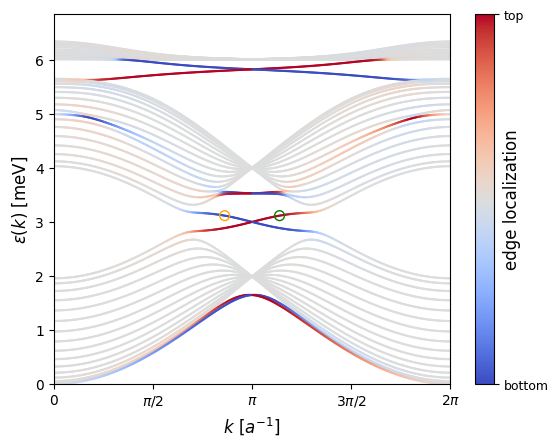

In [6]:
for i in range(nbands):
    bandplot = plt.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# point 1
k_lat = 0.57
E_lat = 3.2
k_index = np.abs(ks - k_lat).argmin()
band_index = np.abs(energies[k_index] - E_lat).argmin()

plt.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# point 1
k_lat2 = 0.43
E_lat2 = 3.2
k_index2 = np.abs(ks - k_lat2).argmin()
band_index2 = np.abs(energies[k_index2] - E_lat2).argmin()

plt.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

cbar = plt.colorbar(bandplot)
cbar.set_label('edge localization', fontsize = 12)
cbar.set_ticks([-1, 1])
cbar.set_ticklabels(['bottom', 'top'])
cbar.ax.yaxis.set_label_coords(1.5, 0.5)
cbar.ax.tick_params(labelsize = 9)

tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
plt.xticks(tick_positions, tick_labels)
plt.xlabel(r'$k \, \, [a^{-1}]$', fontsize=12)
plt.ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=12)
plt.margins(x=0, y=0)
plt.ylim(0,np.max(energies) + 0.5)
plt.savefig('slab_test.pdf', facecolor='w', transparent=False, dpi = 600)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


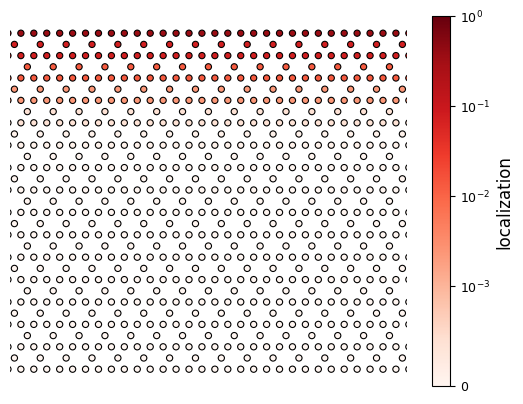

In [7]:
points = np.array([slab.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(slab.lat.sublats))])

for i in range(30):
    latticeplot = plt.scatter(points[:, 0] + i * (slab.lat.num_vects[0,0]), points[:, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index, band_index][:], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

cbar_lat = plt.colorbar(latticeplot) # orientation='horizontal'
cbar_lat.set_label('localization', fontsize = 12)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.tick_params(labelsize = 9)

left_bound = slab.lat.sublats[3*15-1].num_basisvect[0] + slab.lat.num_vects[0,0] + 10*slab.lat.num_vects[0,0]
right_bound = slab.lat.sublats[3-1].num_basisvect[0] - slab.lat.num_vects[0,0] + 20*slab.lat.num_vects[0,0]



plt.axis('off')
plt.axis("equal")
delta = 0.2
plt.xlim(left_bound - delta, right_bound + delta)
plt.savefig('lattice_test.pdf', facecolor='w', transparent=False, dpi = 600)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


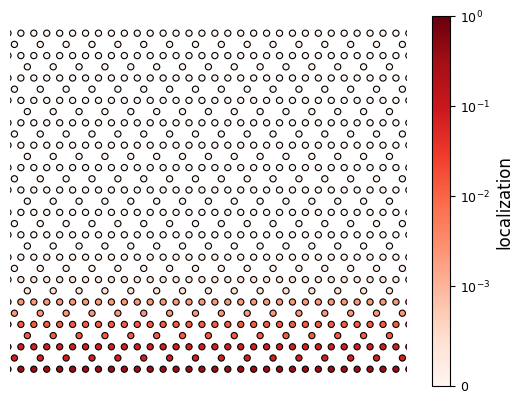

In [8]:
for i in range(30):
    latticeplot2 = plt.scatter(points[:, 0] + i * (slab.lat.num_vects[0,0]), points[:, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index2, band_index2][:], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

cbar3 = plt.colorbar(latticeplot2) # orientation='horizontal'
cbar3.set_label('localization', fontsize = 12)
cbar3.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar3.ax.tick_params(labelsize = 9)


left_bound = slab.lat.sublats[3*15-1].num_basisvect[0] + slab.lat.num_vects[0,0] + 10*slab.lat.num_vects[0,0]
right_bound = slab.lat.sublats[3-1].num_basisvect[0] - slab.lat.num_vects[0,0] + 20*slab.lat.num_vects[0,0]



plt.axis('off')
plt.axis("equal")
delta = 0.2
plt.xlim(left_bound - delta, right_bound + delta)
plt.savefig('lattice_test.pdf', facecolor='w', transparent=False, dpi = 600)

In [8]:
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}"
})

plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

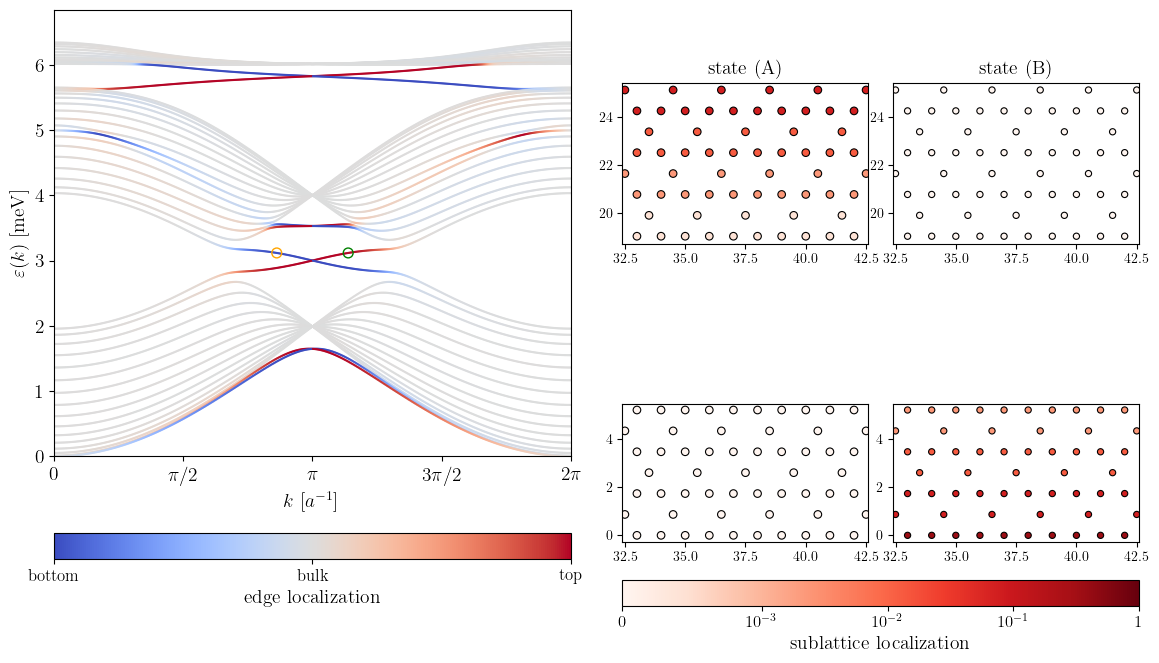

In [10]:
# complete figure setup
fig = plt.figure(figsize=(14, 8))
gs_main = GridSpec(1, 2, width_ratios=[1, 1], wspace=0.1, figure=fig)

# bandstructure: left half
ax_bs = fig.add_subplot(gs_main[0, 0])

# sublattice localization: right half
gs_lat = gs_main[0, 1].subgridspec(1, 2, wspace=0.1)

# top and bottom edged separated
gs_A = gs_lat[0, 0].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.01)
ax_A_bot = fig.add_subplot(gs_A[1, 0])
ax_A_top = fig.add_subplot(gs_A[0, 0])

gs_B = gs_lat[0, 1].subgridspec(2, 1, height_ratios=[1, 1], hspace=0.01)
ax_B_bot = fig.add_subplot(gs_B[1, 0])
ax_B_top = fig.add_subplot(gs_B[0, 0])

# plot bands
for i in range(nbands):
    bandplot = ax_bs.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# mark states
ax_bs.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

ax_bs.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# customize plot
tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax_bs.set_xticks(tick_positions, tick_labels, fontsize = 14)
ax_bs.set_xlabel(r'$k \, \, [a^{-1}]$', fontsize=14)
ax_bs.tick_params(axis='y', labelsize=14)
ax_bs.set_ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=14)
ax_bs.margins(x=0, y=0)
ax_bs.set_ylim(0, np.max(energies) + 0.5)

# customize colorbar
cbar_bs = fig.colorbar(bandplot, ax=ax_bs, pad = 0.125, orientation='horizontal')
cbar_bs.set_label('edge localization', fontsize = 14)
cbar_bs.set_ticks([-1, 0, 1])
cbar_bs.set_ticklabels(['bottom', 'bulk', 'top'])
cbar_bs.ax.yaxis.set_label_coords(1.5, 0.5)
cbar_bs.ax.tick_params(labelsize = 12)

# testing positioning
ucs = 4
bottom = [i for i in range(0, ucs*3-1)]
top = [15*3 - i for i in range(1, ucs*3+1)]

gap = slab.lat.sublats[top[-1]].num_basisvect[1]

reps = 30
squeeze = 8
left_bound = slab.lat.sublats[3*15-1].num_basisvect[0]+ (squeeze + 1)*slab.lat.num_vects[0,0]
right_bound = slab.lat.sublats[3-1].num_basisvect[0] + (reps - squeeze - 1)*slab.lat.num_vects[0,0]
pad = 0.1

for i in range(reps):
    # state A
    latticeplot = ax_A_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot = ax_A_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    # state B
    latticeplot2 = ax_B_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index2, band_index2][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot2 = ax_B_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index2, band_index2][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

ax_A_bot.set_aspect('equal') 
# ax_A_bot.axis('off')
ax_A_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_A_top.set_aspect('equal') 
# ax_A_top.axis('off')
ax_A_top.set_xlim(left_bound - pad, right_bound + pad)
ax_A_top.set_title('state (A)', fontsize=14)

ax_B_bot.set_aspect('equal') 
# ax_B_bot.axis('off')
ax_B_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_B_top.set_aspect('equal') 
# ax_B_top.axis('off')
ax_B_top.set_xlim(left_bound - pad, right_bound + pad)
ax_B_top.set_title('state (B)', fontsize=14)

cbar_lat = fig.colorbar(latticeplot, ax=[ax_A_bot, ax_B_bot], pad = 0.125, orientation='horizontal')
cbar_lat.set_label('sublattice localization', fontsize = 14)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.set_xticklabels([r"$1$", r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$", r"$0$"])
cbar_lat.ax.tick_params(labelsize = 12)

plt.savefig('combined.pdf', facecolor='w', transparent=False, dpi = 600)

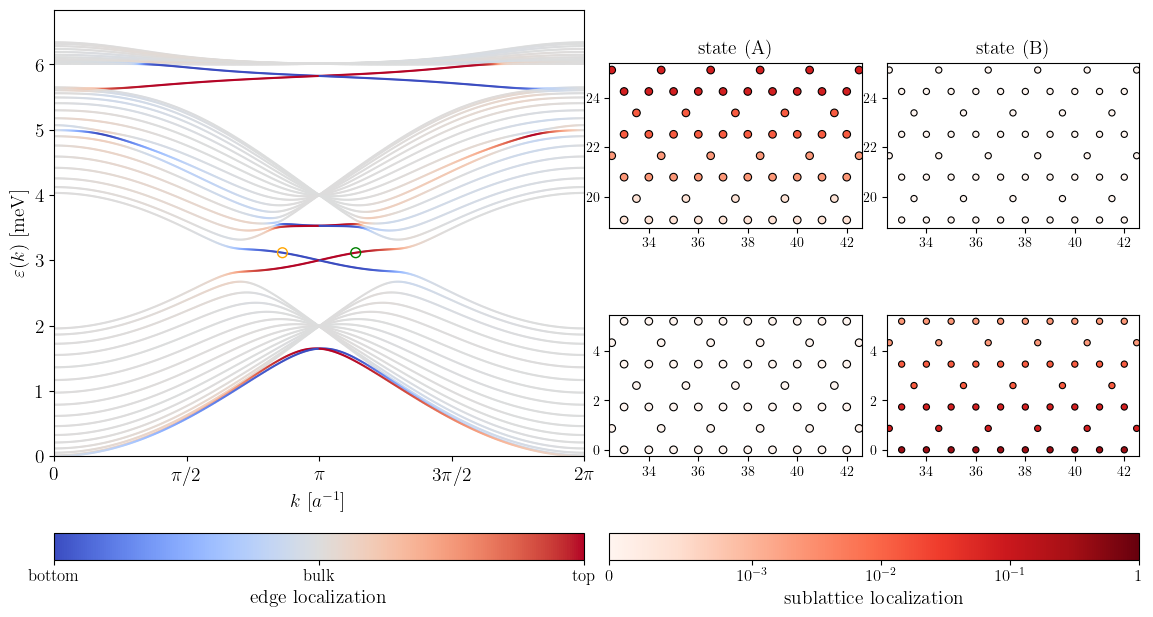

In [11]:
# complete figure setup
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(2, 4, figure=fig, wspace=0.1, hspace=0.05)

# bandstructure: left half
ax_bs = fig.add_subplot(gs[:2, :2])

# sublattice localization: right half, top and bottom edged separated
ax_A_bot = fig.add_subplot(gs[1, 2])
ax_A_top = fig.add_subplot(gs[0, 2])

ax_B_bot = fig.add_subplot(gs[1, 3])
ax_B_top = fig.add_subplot(gs[0, 3])

# plot bands
for i in range(nbands):
    bandplot = ax_bs.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# mark states
ax_bs.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

ax_bs.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# customize plot
tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax_bs.set_xticks(tick_positions, tick_labels, fontsize = 14)
ax_bs.set_xlabel(r'$k \, \, [a^{-1}]$', fontsize=14)
ax_bs.tick_params(axis='y', labelsize=14)
ax_bs.set_ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=14)
ax_bs.margins(x=0, y=0)
ax_bs.set_ylim(0, np.max(energies) + 0.5)

# customize colorbar
cbar_bs = fig.colorbar(bandplot, ax=ax_bs, pad = 0.125, orientation='horizontal')
cbar_bs.set_label('edge localization', fontsize = 14)
cbar_bs.set_ticks([-1, 0, 1])
cbar_bs.set_ticklabels(['bottom', 'bulk', 'top'])
cbar_bs.ax.yaxis.set_label_coords(1.5, 0.5)
cbar_bs.ax.tick_params(labelsize = 12)

# testing positioning
ucs = 4
bottom = [i for i in range(0, ucs*3-1)]
top = [15*3 - i for i in range(1, ucs*3 + 1)]

gap = slab.lat.sublats[top[-1]].num_basisvect[1]

reps = 30
squeeze = 8
left_bound = slab.lat.sublats[3*15-1].num_basisvect[0]+ (squeeze + 1)*slab.lat.num_vects[0,0]
right_bound = slab.lat.sublats[3-1].num_basisvect[0] + (reps - squeeze - 1)*slab.lat.num_vects[0,0]
pad = 0.1

for i in range(reps):
    # state A
    latticeplot = ax_A_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot = ax_A_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    # state B
    latticeplot2 = ax_B_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index2, band_index2][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot2 = ax_B_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 20, c = amps[k_index2, band_index2][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

ax_A_bot.set_aspect('equal') 
# ax_A_bot.axis('off')
ax_A_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_A_top.set_aspect('equal') 
# ax_A_top.axis('off')
ax_A_top.set_xlim(left_bound - pad, right_bound + pad)
ax_A_top.set_title('state (A)', fontsize=14)

ax_B_bot.set_aspect('equal') 
# ax_B_bot.axis('off')
ax_B_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_B_top.set_aspect('equal') 
# ax_B_top.axis('off')
ax_B_top.set_xlim(left_bound - pad, right_bound + pad)
ax_B_top.set_title('state (B)', fontsize=14)

cbar_lat = fig.colorbar(latticeplot, ax=[ax_A_bot, ax_B_bot, ax_A_top, ax_B_top], pad = 0.125, orientation='horizontal')
cbar_lat.set_label('sublattice localization', fontsize = 14)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.set_xticklabels([r"$1$", r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$", r"$0$"])
cbar_lat.ax.tick_params(labelsize = 12)

plt.savefig('combined.pdf', facecolor='w', transparent=False, dpi = 600)

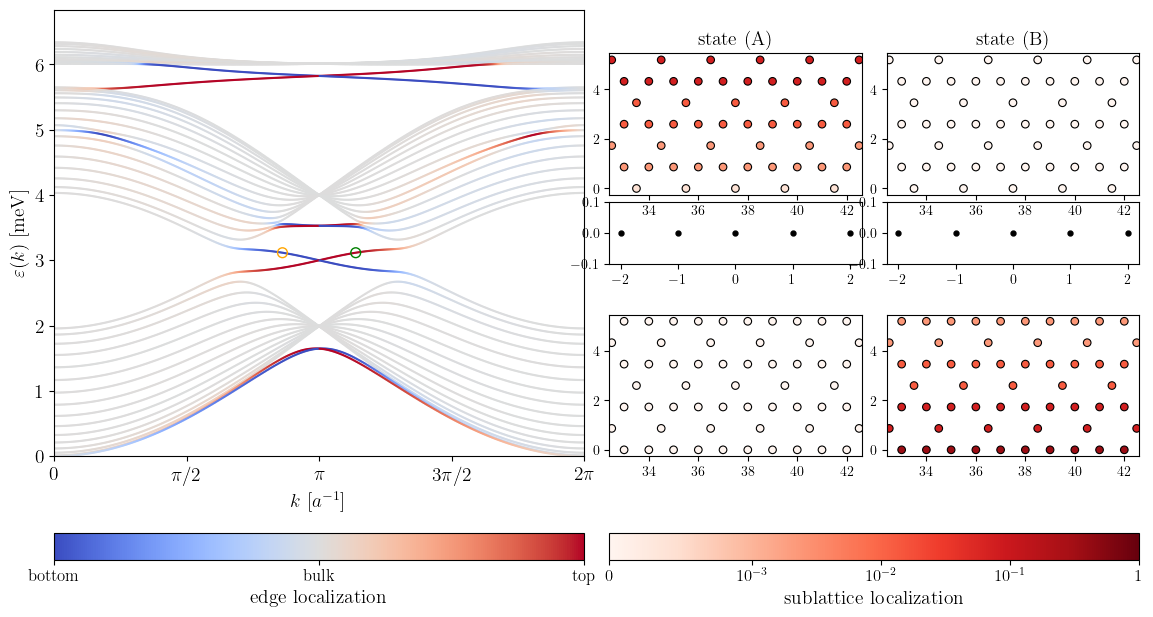

In [12]:
# complete figure setup
fig = plt.figure(figsize=(14, 8))
gs = GridSpec(3, 4, figure=fig, wspace=0.1, hspace=0.05, height_ratios=[3, 1, 3])

# bandstructure: left half
ax_bs = fig.add_subplot(gs[:3, :2])

# sublattice localization: right half, top and bottom edged separated, gap in between
ax_A_bot = fig.add_subplot(gs[2, 2])
ax_A_gap = fig.add_subplot(gs[1, 2])
ax_A_top = fig.add_subplot(gs[0, 2])

ax_B_bot = fig.add_subplot(gs[2, 3])
ax_B_gap = fig.add_subplot(gs[1, 3])
ax_B_top = fig.add_subplot(gs[0, 3])



# plot bands
for i in range(nbands):
    bandplot = ax_bs.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# mark states
ax_bs.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

ax_bs.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# customize plot
tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax_bs.set_xticks(tick_positions, tick_labels, fontsize = 14)
ax_bs.set_xlabel(r'$k \, \, [a^{-1}]$', fontsize=14)
ax_bs.tick_params(axis='y', labelsize=14)
ax_bs.set_ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=14)
ax_bs.margins(x=0, y=0)
ax_bs.set_ylim(0, np.max(energies) + 0.5)

# customize colorbar
cbar_bs = fig.colorbar(bandplot, ax=ax_bs, pad = 0.125, orientation='horizontal')
cbar_bs.set_label('edge localization', fontsize = 14)
cbar_bs.set_ticks([-1, 0, 1])
cbar_bs.set_ticklabels(['bottom', 'bulk', 'top'])
cbar_bs.ax.yaxis.set_label_coords(1.5, 0.5)
cbar_bs.ax.tick_params(labelsize = 12)

# testing positioning
ucs = 4
bottom = [i for i in range(0, ucs*3-1)]
top = [15*3 - i for i in range(1, ucs*3 - 1)]

gap = slab.lat.sublats[top[-1]].num_basisvect[1]

reps = 30
squeeze = 8
left_bound = slab.lat.sublats[3*15-1].num_basisvect[0]+ (squeeze + 1)*slab.lat.num_vects[0,0]
right_bound = slab.lat.sublats[3-1].num_basisvect[0] + (reps - squeeze - 1)*slab.lat.num_vects[0,0]
pad = 0.1

for i in range(reps):
    # state A
    latticeplot = ax_A_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot = ax_A_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1] - gap, marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index, band_index][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    # state B
    latticeplot2 = ax_B_bot.scatter(points[bottom, 0] + i * (slab.lat.num_vects[0,0]), points[bottom, 1], marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index2, band_index2][bottom], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

    latticeplot2 = ax_B_top.scatter(points[top, 0] + i * (slab.lat.num_vects[0,0]), points[top, 1] - gap, marker = "o", edgecolors = "black", linewidths = 0.8, s = 30, c = amps[k_index2, band_index2][top], cmap = 'Reds', norm = SymLogNorm(0.001, vmin=0, vmax=1))

ax_A_bot.set_aspect('equal') 
# ax_A_bot.axis('off')
ax_A_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_A_top.set_aspect('equal') 
# ax_A_top.axis('off')
ax_A_top.set_xlim(left_bound - pad, right_bound + pad)
ax_A_top.set_title('state (A)', fontsize=14)

ax_B_bot.set_aspect('equal') 
# ax_B_bot.axis('off')
ax_B_bot.set_xlim(left_bound - pad, right_bound + pad)

ax_B_top.set_aspect('equal') 
# ax_B_top.axis('off')
ax_B_top.set_xlim(left_bound - pad, right_bound + pad)
ax_B_top.set_title('state (B)', fontsize=14)

cbar_lat = fig.colorbar(latticeplot, ax=[ax_A_bot, ax_B_bot, ax_A_top, ax_B_top, ax_A_gap, ax_B_gap], pad = 0.125, orientation='horizontal')
cbar_lat.set_label('sublattice localization', fontsize = 14)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.set_xticklabels([r"$1$", r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$", r"$0$"])
cbar_lat.ax.tick_params(labelsize = 12)



dots_x = [-2, -1, 0, 1, 2]
dots_y = [0,0,0,0,0] #[[-1,0,1], [-1,0,1], [-1,0,1], [-1,0,1], [-1,0,1]]



# ax_A_gap.set_aspect('equal') 
# ax_B_gap.set_aspect('equal') 

ax_A_gap.scatter(dots_x, dots_y, facecolors = 'black', marker = '.', s = 50)
ax_B_gap.scatter(dots_x, dots_y, facecolors = 'black', marker = '.', s = 50)
ax_A_gap.set_ylim(-0.1, 0.1)
ax_B_gap.set_ylim(-0.1, 0.1)

plt.savefig('combined.pdf', facecolor='w', transparent=False, dpi = 600)

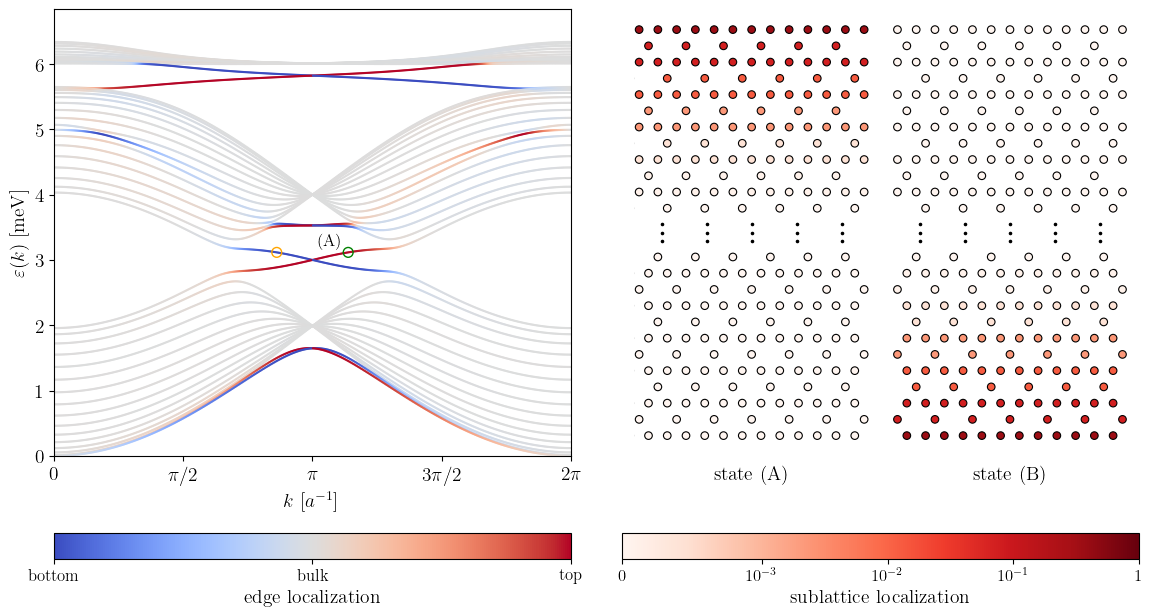

In [13]:
points = np.array([slab.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(slab.lat.sublats))])

# complete figure setup
fig = plt.figure(figsize=(14, 8))
gs_main = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.1)

# bandstructure: left half
ax_bs = fig.add_subplot(gs_main[0, 0])

# sublattice localization: right half
gs_lat = gs_main[0, 1].subgridspec(1, 2, wspace=0)
ax_A = fig.add_subplot(gs_lat[0, 0])
ax_B = fig.add_subplot(gs_lat[0, 1])

# plot bands
for i in range(nbands):
    bandplot = ax_bs.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# mark states
ax_bs.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

ax_bs.text(ks[k_index] - 0.01, energies[k_index,band_index] + 0.05, '(A)', 
        fontsize=12, ha='right', va='bottom')

ax_bs.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# customize plot
tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax_bs.set_xticks(tick_positions, tick_labels, fontsize = 14)
ax_bs.set_xlabel(r'$k \, \, [a^{-1}]$', fontsize=14)
ax_bs.tick_params(axis='y', labelsize=14)
ax_bs.set_ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=14)
ax_bs.margins(x=0, y=0)
ax_bs.set_ylim(0, np.max(energies) + 0.5)

# customize colorbar
cbar_bs = fig.colorbar(bandplot, ax=ax_bs, pad = 0.125, orientation='horizontal')
cbar_bs.set_label('edge localization', fontsize = 14)
cbar_bs.set_ticks([-1, 0, 1])
cbar_bs.set_ticklabels(['bottom', 'bulk', 'top'])
cbar_bs.ax.yaxis.set_label_coords(1.5, 0.5)
cbar_bs.ax.tick_params(labelsize = 12)

# plot lattice
# top and bottom layers
n_ucs = 20
n_per_uc = 3
uc_layers = 6
id_range = n_per_uc * uc_layers

bot_ids = [i for i in range(0, id_range)]
top_ids = [slab.lat.n_sublats - i for i in range(1, id_range + 1)]

x_bot = points[bot_ids, 0]
y_bot = points[bot_ids, 1]

x_top = points[top_ids, 0]
y_top = points[top_ids, 1]

c_bot_A = amps[k_index, band_index][bot_ids]
c_top_A = amps[k_index, band_index][top_ids]
c_bot_B = amps[k_index2, band_index2][bot_ids]
c_top_B = amps[k_index2, band_index2][top_ids]

lognorm = SymLogNorm(0.001, vmin=0, vmax=1)

# replicate in x direction, select fitting region
reps = 10

x_shift = slab.lat.num_vects[0,0]
y_shift = slab.lat.num_vects[1,1]
top_shift_left = np.min(x_top)
y_gap = np.min(y_top) - np.max(y_bot)
buffer = 1.5 * y_shift
top_shift_down = y_gap - buffer

padding = 0.25
x_offset = 0.5
left_bound = np.max(x_bot) - padding + x_offset
right_bound = np.min(x_bot) + (reps - 1) * x_shift + padding + x_offset

for i in range(reps):
    latplot_A = ax_A.scatter(x_bot + i * x_shift, y_bot,
                             marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
                             c = c_bot_A,
                             cmap = 'Reds', norm = lognorm)
    
    latplot_A = ax_A.scatter(x_top + i * x_shift - top_shift_left, y_top - top_shift_down,
                             marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
                             c = c_top_A,
                             cmap = 'Reds', norm = lognorm)
    
    latplot_B = ax_B.scatter(x_bot + i * x_shift, y_bot,
                             marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
                             c = c_bot_B,
                             cmap = 'Reds', norm = lognorm)
    
    latplot_B = ax_B.scatter(x_top + i * x_shift - top_shift_left, y_top - top_shift_down,
                             marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
                             c = c_top_B,
                             cmap = 'Reds', norm = lognorm)
    
# add dots to mark bulk gap
center_x = right_bound - left_bound
center_y = (np.min(y_top)- top_shift_down + np.max(y_bot)) / 2

for i in [-2, -1, 0, 1, 2]:
    for j in [-1, 0, 1]:
        ax_A.scatter(center_x + 30*i / np.abs(center_x), center_y + 5 * j / np.abs(center_y), marker = ".", facecolor = 'black', s = 10)
        ax_B.scatter(center_x + 30*i / np.abs(center_x), center_y + 5 * j / np.abs(center_y), marker = ".", facecolor = 'black', s = 10)

# customize plots
ax_A.set_aspect('equal') 
ax_A.axis('off')
ax_A.set_xlim(left_bound, right_bound)
ax_A.set_title('state (A)', fontsize=14, y=-0.1, pad=15)

ax_B.set_aspect('equal') 
ax_B.axis('off')
ax_B.set_xlim(left_bound, right_bound)
ax_B.set_title('state (B)', fontsize=14, y=-0.1, pad=15)

# customize colorbar
cbar_lat = fig.colorbar(latplot_A, ax=[ax_A, ax_B], pad = 0.125, orientation='horizontal')
cbar_lat.set_label('sublattice localization', fontsize = 14)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.set_xticklabels([r"$1$", r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$", r"$0$"])
cbar_lat.ax.tick_params(labelsize = 12)

plt.savefig('combined.pdf', facecolor='w', transparent=False, dpi = 600)

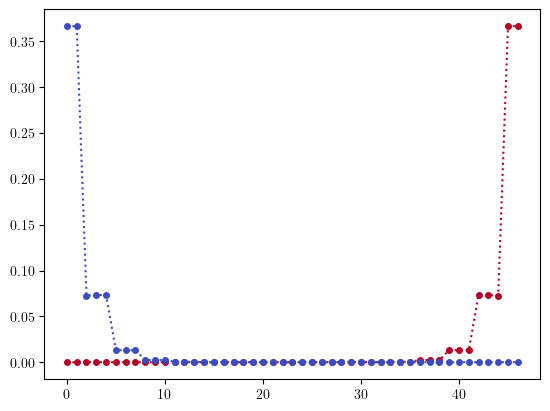

In [14]:
cmap = plt.get_cmap('coolwarm')
norm = Normalize(vmin=0, vmax=1)
color_min = cmap(norm(0))
color_max = cmap(norm(1))

x = [i for i in range(slab.lat.n_sublats)]
y1 = [amps[k_index, band_index][i] for i in range(slab.lat.n_sublats)]
y2 = [amps[k_index2, band_index2][i] for i in range(slab.lat.n_sublats)]

plt.plot(x, y1, 'o:', markersize=4, linewidth=1.5, color=color_max)
plt.plot(x, y2, 'o:', markersize=4, linewidth=1.5, color=color_min)

In [15]:
# latex styling
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "text.latex.preamble": r"\usepackage{lmodern}"})
plt.rcParams['text.usetex'] = True
plt.rcParams['text.latex.preamble'] = r'\usepackage{bm}'

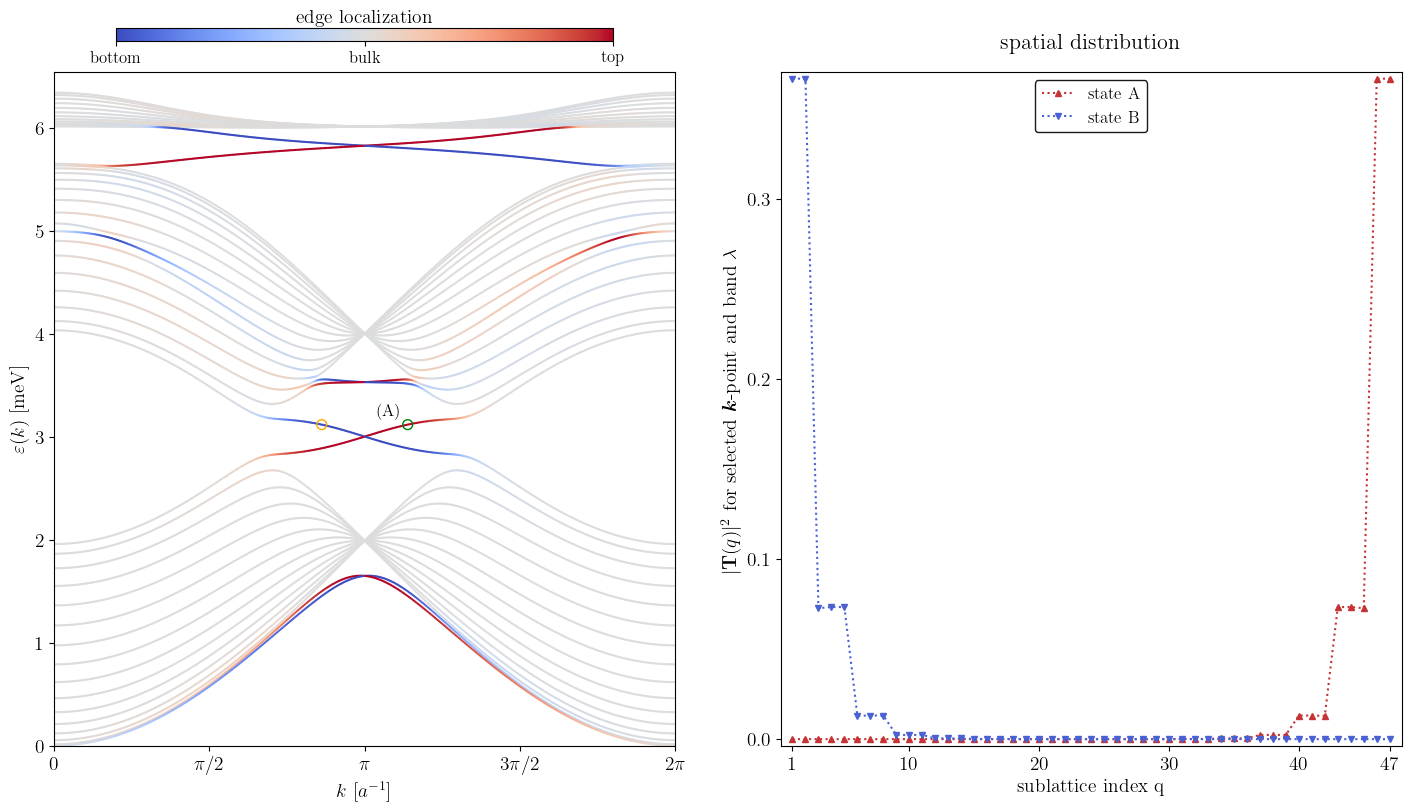

In [9]:
points = np.array([slab.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(slab.lat.sublats))])

# complete figure setup
fig = plt.figure(figsize=(14, 8), constrained_layout=True)
gs_main = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.05)

# bandstructure: left half
ax_bs = fig.add_subplot(gs_main[0, 0])

# spatial distribution: right half
ax_sd = fig.add_subplot(gs_main[0, 1])

# plot bands
for i in range(nbands):
    bandplot = ax_bs.scatter(ks, energies[:,i], marker = '.', c = loc[:, i], edgecolor='none', cmap = 'coolwarm', vmin = -1.0, vmax = 1.0, s = 10)

# mark states
ax_bs.scatter(ks[k_index],energies[k_index,band_index], facecolors = 'none', edgecolors= 'green', marker = 'o', linewidths = 1, s = 50, zorder = 3)

ax_bs.text(ks[k_index] - 0.01, energies[k_index,band_index] + 0.05, '(A)', 
        fontsize=12, ha='right', va='bottom')

ax_bs.scatter(ks[k_index2],energies[k_index2,band_index2], facecolors = 'none', edgecolors= 'orange', marker = 'o', linewidths = 1, s = 50, zorder = 3)

# customize plot
tick_positions = [0, 0.25, 0.5, 0.75, 1]
tick_labels = [r"$0$", r"$\pi/2$", r"$\pi$", r"$3\pi/2$", r"$2\pi$"]
ax_bs.set_xticks(tick_positions, tick_labels, fontsize = 14)
ax_bs.set_xlabel(r'$k \, \, [a^{-1}]$', fontsize=14)
ax_bs.tick_params(axis='y', labelsize=14)
ax_bs.set_ylabel(r'$\varepsilon(k) \, \, [\mathrm{meV}]$', fontsize=14)
ax_bs.margins(x=0, y=0)
ax_bs.set_ylim(0, np.max(energies) + 0.2)

# customize colorbar
cbar_bs = fig.colorbar(bandplot, ax=ax_bs, pad = 0.01, orientation='horizontal', location='top', shrink=0.8, aspect=40)
cbar_bs.set_label('edge localization', fontsize = 14)
cbar_bs.set_ticks([-1, 0, 1])
cbar_bs.set_ticklabels(['bottom', 'bulk', 'top'])
cbar_bs.ax.tick_params(labelsize = 12)
cbar_bs.ax.xaxis.set_ticks_position('bottom')
cbar_bs.ax.xaxis.set_label_position('top')

# plot spatial distribution
sites = [i + 1 for i in range(slab.lat.n_sublats)]
amp_A = [amps[k_index, band_index, i] for i in range(slab.lat.n_sublats)]
amp_B = [amps[k_index2, band_index2, i] for i in range(slab.lat.n_sublats)]

# get colors from colorbar for clear visualization
cmap = plt.get_cmap('coolwarm')
cnorm = Normalize(vmin=0, vmax=1)
color_min = cmap(cnorm(0.05))
color_max = cmap(cnorm(0.95))

ax_sd.plot(sites, amp_A, '^:', markersize=4, linewidth=1.5, color=color_max, label='state A')
ax_sd.plot(sites, amp_B, 'v:', markersize=4, linewidth=1.5, color=color_min, label='state B')

# customize plot
first, last = 1, slab.lat.n_sublats
ticks = ax_sd.get_xticks()
# Ensure first and last are included
if ticks[0] != first:
    ticks = np.insert(ticks, 0,first)
if ticks[-1] != last:
    ticks = np.append(ticks, last)
ax_sd.set_xticks(ticks)
ax_sd.tick_params(axis = 'x', labelsize=14)
ax_sd.set_xlabel('sublattice index q', fontsize=14)
yticks = ax_sd.get_yticks()
ax_sd.set_yticks(yticks[1::2])
ax_sd.tick_params(axis = 'y', labelsize=14)
ax_sd.set_ylabel(r'$\vert \mathbf{T}(q) \vert^2$ for selected $\bm{k}$-point and band $\lambda$', fontsize=14)
ax_sd.margins(x=0.02, y=0.01)
ax_sd.legend(
    loc='upper center',
    fontsize=12,
    frameon=True,
    framealpha=0.9,
    edgecolor='black',
    facecolor='white',
)

fig.text(0.775, 0.945, 'spatial distribution', ha='center', fontsize=16)

plt.savefig('slab bs + spatdist.pdf', facecolor='w', transparent=False, dpi = 600)

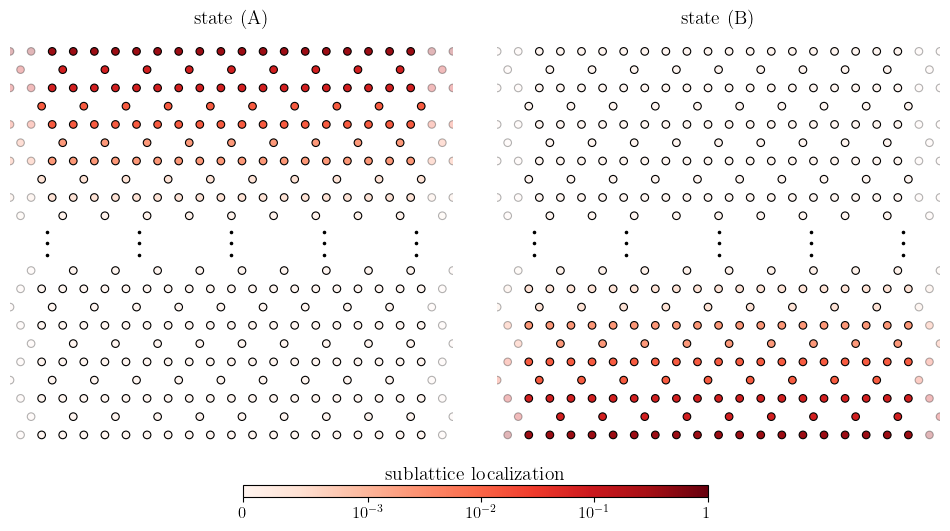

In [86]:
points = np.array([slab.lat.sublats[i].num_basisvect[0:2] for i in range(0, len(slab.lat.sublats))])

# complete figure setup
fig = plt.figure(figsize=(12, 8))
gs_lat = GridSpec(1, 2, figure=fig, width_ratios=[1, 1], wspace=0.1)

ax_A = fig.add_subplot(gs_lat[0, 0])
ax_B = fig.add_subplot(gs_lat[0, 1])

# plot lattice
# top and bottom layers
n_ucs = 20
n_per_uc = 3
uc_layers = 5
id_range = n_per_uc * uc_layers

bot_ids = [i for i in range(0, id_range)]
top_ids = [slab.lat.n_sublats - i for i in range(1, id_range + 1)]

x_bot = points[bot_ids, 0]
y_bot = points[bot_ids, 1]

x_top = points[top_ids, 0]
y_top = points[top_ids, 1]

c_bot_A = amps[k_index, band_index][bot_ids]
c_top_A = amps[k_index, band_index][top_ids]
c_bot_B = amps[k_index2, band_index2][bot_ids]
c_top_B = amps[k_index2, band_index2][top_ids]

lognorm = SymLogNorm(0.001, vmin=0, vmax=1)

# replicate in x direction, select fitting region
reps = 14

x_shift = slab.lat.num_vects[0,0]
y_shift = slab.lat.num_vects[1,1]
top_shift_left = np.min(x_top)
y_gap = np.min(y_top) - np.max(y_bot)
buffer = 1.5 * y_shift
top_shift_down = y_gap - buffer

left_pad = 0
right_pad = 0
x_offset = 0.5
left_bound = np.max(x_bot) + left_pad + x_offset
right_bound = np.min(x_bot) + (reps - 1) * x_shift + right_pad + x_offset

# for i in range(reps):
#     x_bot_rep = x_bot + i * x_shift
#     x_top_rep = x_top + i * x_shift - top_shift_left


#     latplot_A = ax_A.scatter(x_bot_rep, y_bot,
#                              marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
#                              c = c_bot_A,
#                              cmap = 'Reds', norm = lognorm)
    
#     latplot_A = ax_A.scatter(x_top_rep, y_top - top_shift_down,
#                              marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
#                              c = c_top_A,
#                              cmap = 'Reds', norm = lognorm)
    
#     latplot_B = ax_B.scatter(x_bot_rep, y_bot,
#                              marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
#                              c = c_bot_B,
#                              cmap = 'Reds', norm = lognorm)
    
#     latplot_B = ax_B.scatter(x_top_rep, y_top - top_shift_down,
#                              marker = "o", edgecolors = "black", linewidths = 0.8, s = 30,
#                              c = c_top_B,
#                              cmap = 'Reds', norm = lognorm)

x_bot_all = np.concatenate([x_bot + i * x_shift for i in range(reps)])
x_top_all = np.concatenate([x_top + i * x_shift - top_shift_left for i in range(reps)])
y_bot_all = np.concatenate([y_bot for _ in range(reps)])
y_top_all = np.concatenate([y_top - top_shift_down for _ in range(reps)])
c_bot_A_all = np.concatenate([c_bot_A for _ in range(reps)])
c_top_A_all = np.concatenate([c_top_A for _ in range(reps)])
c_bot_B_all = np.concatenate([c_bot_B for _ in range(reps)])
c_top_B_all = np.concatenate([c_top_B for _ in range(reps)])

# add fade out effect at bounds
fade_mask_bot = (x_bot_all < left_bound + 1.5) | (x_bot_all > right_bound - 1.5)

alphas_bot = np.ones_like(x_bot_all)
alphas_bot[fade_mask_bot] = 0.3

fade_mask_top = (x_top_all < left_bound + 1.5) | (x_top_all > right_bound - 1.5)

alphas_top = np.ones_like(x_top_all)
alphas_top[fade_mask_top] = 0.3

# fade_width = 1

# # Distance outside left bound (positive if outside)
# dist_left = np.maximum(0, left_bound + 1 - x_bot_all)
# # Distance outside right bound (positive if outside)
# dist_right = np.maximum(0, x_bot_all - right_bound - 1)

# # Combined distance (how far outside either bound)
# dist_outside = dist_left + dist_right

# # Alpha: 1.0 inside bounds, fades to 0 outside
# alphas = 1.0 - np.clip(dist_outside / fade_width, 0, 1)

latplot_A_bot = ax_A.scatter(x_bot_all, y_bot_all,
                            marker="o", edgecolors="black", linewidths=0.8, s=30,
                            c=c_bot_A_all, cmap='Reds', norm=lognorm,
                            alpha=alphas_bot)

latplot_A_top = ax_A.scatter(x_top_all, y_top_all,
                            marker="o", edgecolors="black", linewidths=0.8, s=30,
                            c=c_top_A_all, cmap='Reds', norm=lognorm,
                            alpha=alphas_top)

latplot_B_bot = ax_B.scatter(x_bot_all, y_bot_all,
                            marker="o", edgecolors="black", linewidths=0.8, s=30,
                            c=c_bot_B_all, cmap='Reds', norm=lognorm,
                            alpha=alphas_bot)

latplot_B_top = ax_B.scatter(x_top_all, y_top_all,
                            marker="o", edgecolors="black", linewidths=0.8, s=30,
                            c=c_top_B_all, cmap='Reds', norm=lognorm,
                            alpha=alphas_top)
    
# add dots to mark bulk gap
center_x = (right_bound + left_bound) / 2
center_y = (np.min(y_top)- top_shift_down + np.max(y_bot)) / 2

for i in [-2, -1, 0, 1, 2]:
    for j in [-1, 0, 1]:
        ax_A.scatter(center_x + 70*i / np.abs(center_x), center_y + 5 * j / np.abs(center_y), marker = ".", facecolor = 'black', s = 10)
        ax_B.scatter(center_x + 70*i / np.abs(center_x), center_y + 5 * j / np.abs(center_y), marker = ".", facecolor = 'black', s = 10)

# customize plots
ax_A.set_aspect('equal') 
ax_A.axis('off')
ax_A.set_xlim(left_bound, right_bound)
ax_A.set_title('state (A)', fontsize=14)

ax_B.set_aspect('equal') 
ax_B.axis('off')
ax_B.set_xlim(left_bound, right_bound)
ax_B.set_title('state (B)', fontsize=14)

# customize colorbar
cbar_lat = fig.colorbar(latplot_A_bot, ax=[ax_A, ax_B], pad = 0.05, orientation='horizontal', shrink = 0.5, aspect=40)
cbar_lat.set_label('sublattice localization', fontsize = 14)
cbar_lat.set_ticks([1, 10**-1, 10**-2, 10**-3, 0])
cbar_lat.ax.set_xticklabels([r"$1$", r"$10^{-1}$", r"$10^{-2}$", r"$10^{-3}$", r"$0$"])
cbar_lat.ax.tick_params(labelsize = 12)
cbar_lat.ax.xaxis.set_label_position('top')

plt.savefig('combined.pdf', facecolor='w', transparent=False, dpi = 600)